# AgriSense — Vegetable Price Dataset: Exploratory Data Analysis




In [1]:
# 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Greens_r")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = "datasettttt.xlsx"   # <-- change if needed
pd.set_option("display.max_columns", None)


## 2. Load the raw file

In [2]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=0)
print("Shape:", df_raw.shape)
df_raw.head(12)


Shape: (2340, 4)


,Date,Price,Vegetable,District
0,28/1/2021,195,Beans,Kandy
1,NaN,440,Cabbage,NaN
2,NaN,135,Carrots,NaN
3,NaN,170,Ocra,NaN
4,NaN,55,Leeks,NaN
5,2021-04-02 00:00:00,145,Beans,Matale
6,NaN,75,Cabbage,NaN
7,NaN,125,Carrots,NaN
8,NaN,85,Ocra,NaN
9,NaN,75,Leeks,NaN


## 3. Clean the data



In [3]:
df = df_raw.copy()

# --- forward-fill the block-grouped columns ---
df["Date"] = df["Date"].ffill()
df["District"] = df["District"].ffill()

# --- normalise the crop name typo so it matches the AgriSense schema ---
df["Vegetable"] = df["Vegetable"].replace({"Ocra": "Okra"})

# --- parse Date: text values need dayfirst=True, datetime values pass through untouched ---
def parse_mixed_date(value):
    if isinstance(value, str):
        return pd.to_datetime(value, dayfirst=True, errors="coerce")
    return pd.to_datetime(value, errors="coerce")

df["Date"] = df["Date"].apply(parse_mixed_date)

# --- Price: force numeric, coercing anything non-numeric to NaN so we can see it ---
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df = df.rename(columns={"Vegetable": "Crop"})
df = df[["Date", "District", "Crop", "Price"]].sort_values(["Date", "District", "Crop"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df.head(10)


Shape after cleaning: (2340, 4)


,Date,District,Crop,Price
0,2021-01-04,Kandy,Beans,175.0
1,2021-01-04,Kandy,Cabbage,65.0
2,2021-01-04,Kandy,Carrots,125.0
3,2021-01-04,Kandy,Leeks,75.0
4,2021-01-04,Kandy,Okra,75.0
5,2021-01-04,Matale,Beans,165.0
6,2021-01-04,Matale,Cabbage,75.0
7,2021-01-04,Matale,Carrots,120.0
8,2021-01-04,Matale,Leeks,75.0
9,2021-01-04,Matale,Okra,55.0


## 4. Data-quality report




In [5]:
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print()
print("Rows per crop:")
print(df["Crop"].value_counts())
print()
print("Rows per district:")
print(df["District"].value_counts())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print(f"Duplicate (Date, District, Crop) rows: {df.duplicated(subset=['Date','District','Crop']).sum()}")


Date range: 2021-01-04 to 2025-12-04

Rows per crop:
Crop
Beans      468
Cabbage    468
Carrots    468
Leeks      468
Okra       468
Name: count, dtype: int64

Rows per district:
District
Matale    1174
Kandy     1166
Name: count, dtype: int64

Missing values:
Date         0
District     0
Crop         0
Price       40
dtype: int64

Duplicate (Date, District, Crop) rows: 15


In [6]:
# Rows with a missing price — decide whether to drop, interpolate, or fill from source
missing_price = df[df["Price"].isnull()]
print(f"{len(missing_price)} rows with missing price:")
missing_price


40 rows with missing price:


,Date,District,Crop,Price
135,2021-05-13,Matale,Beans,NaN
136,2021-05-13,Matale,Cabbage,NaN
137,2021-05-13,Matale,Carrots,NaN
138,2021-05-13,Matale,Leeks,NaN
139,2021-05-13,Matale,Okra,NaN
145,2021-05-20,Matale,Beans,NaN
146,2021-05-20,Matale,Cabbage,NaN
147,2021-05-20,Matale,Carrots,NaN
148,2021-05-20,Matale,Leeks,NaN
149,2021-05-20,Matale,Okra,NaN


In [7]:
# Ambiguous-looking dates worth a manual sanity check:
# original Excel datetime cells where BOTH day and month are <= 12 (e.g. 2021-04-02 could be
# 2 Apr or 4 Feb depending on how Excel originally parsed it). Text dates were already parsed
# correctly with dayfirst=True, so this only flags rows that came in as native datetimes.
ambiguous = df[(df["Date"].dt.day <= 12) & (df["Date"].dt.month <= 12)]
print(f"{len(ambiguous)} rows with day<=12 and month<=12 (can't tell day/month from the value alone).")
print("Spot-check a sample against the original spreadsheet if exact dates matter:")
ambiguous.sample(min(10, len(ambiguous)), random_state=1).sort_values("Date")


890 rows with day<=12 and month<=12 (can't tell day/month from the value alone).
Spot-check a sample against the original spreadsheet if exact dates matter:


,Date,District,Crop,Price
3,2021-01-04,Kandy,Leeks,75.0
79,2021-04-02,Matale,Okra,85.0
169,2021-07-10,Matale,Okra,55.0
383,2022-01-09,Matale,Leeks,150.0
578,2022-06-10,Kandy,Leeks,260.0
626,2022-07-07,Kandy,Cabbage,235.0
1420,2024-02-01,Matale,Beans,700.0
1662,2024-08-01,Kandy,Carrots,310.0
1769,2024-10-10,Matale,Okra,95.0
2261,2025-10-09,Kandy,Cabbage,60.0


## 5. Handle missing prices




In [8]:
df["Month"] = df["Date"].dt.to_period("M")

month_median = df.groupby(["Crop", "District", "Month"])["Price"].transform("median")
df["Price_filled"] = df["Price"].fillna(month_median)

overall_median = df.groupby(["Crop", "District"])["Price"].transform("median")
df["Price_filled"] = df["Price_filled"].fillna(overall_median)

df["Price"] = df["Price_filled"]
df = df.drop(columns=["Price_filled", "Month"])

print("Remaining missing prices:", df["Price"].isnull().sum())


Remaining missing prices: 0


## 6. Descriptive statistics

In [9]:
summary = df.groupby(["Crop", "District"])["Price"].agg(
    count="count", mean="mean", median="median", std="std", min="min", max="max"
).round(1)
summary


count   mean  median    std   min     max
Crop    District                                           
Beans   Kandy       233  331.4   325.0  146.6  65.0   950.0
        Matale      235  320.1   315.0  142.0  45.0   925.0
Cabbage Kandy       233  165.9   145.0   97.9  50.0   560.0
        Matale      235  162.9   140.0   98.6  33.0   640.0
Carrots Kandy       233  273.0   255.0  193.0  60.0  1550.0
        Matale      235  267.4   240.0  197.7  70.0  1650.0
Leeks   Kandy       234  187.3   175.0   91.8  45.0   545.0
        Matale      234  187.6   175.0   88.3  55.0   575.0
Okra    Kandy       233  138.4   130.0   60.2  40.0   360.0
        Matale      235  120.2   105.0   61.5  30.0   360.0

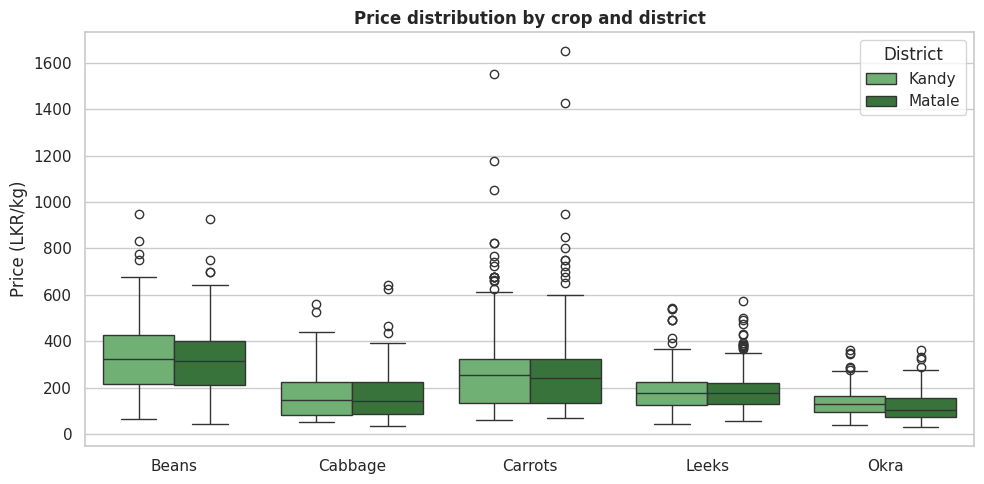

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Crop", y="Price", hue="District", palette=["#66BB6A", "#2E7D32"])
plt.title("Price distribution by crop and district")
plt.ylabel("Price (LKR/kg)")
plt.xlabel("")
plt.tight_layout()
plt.show()


## 7. Price trends over time

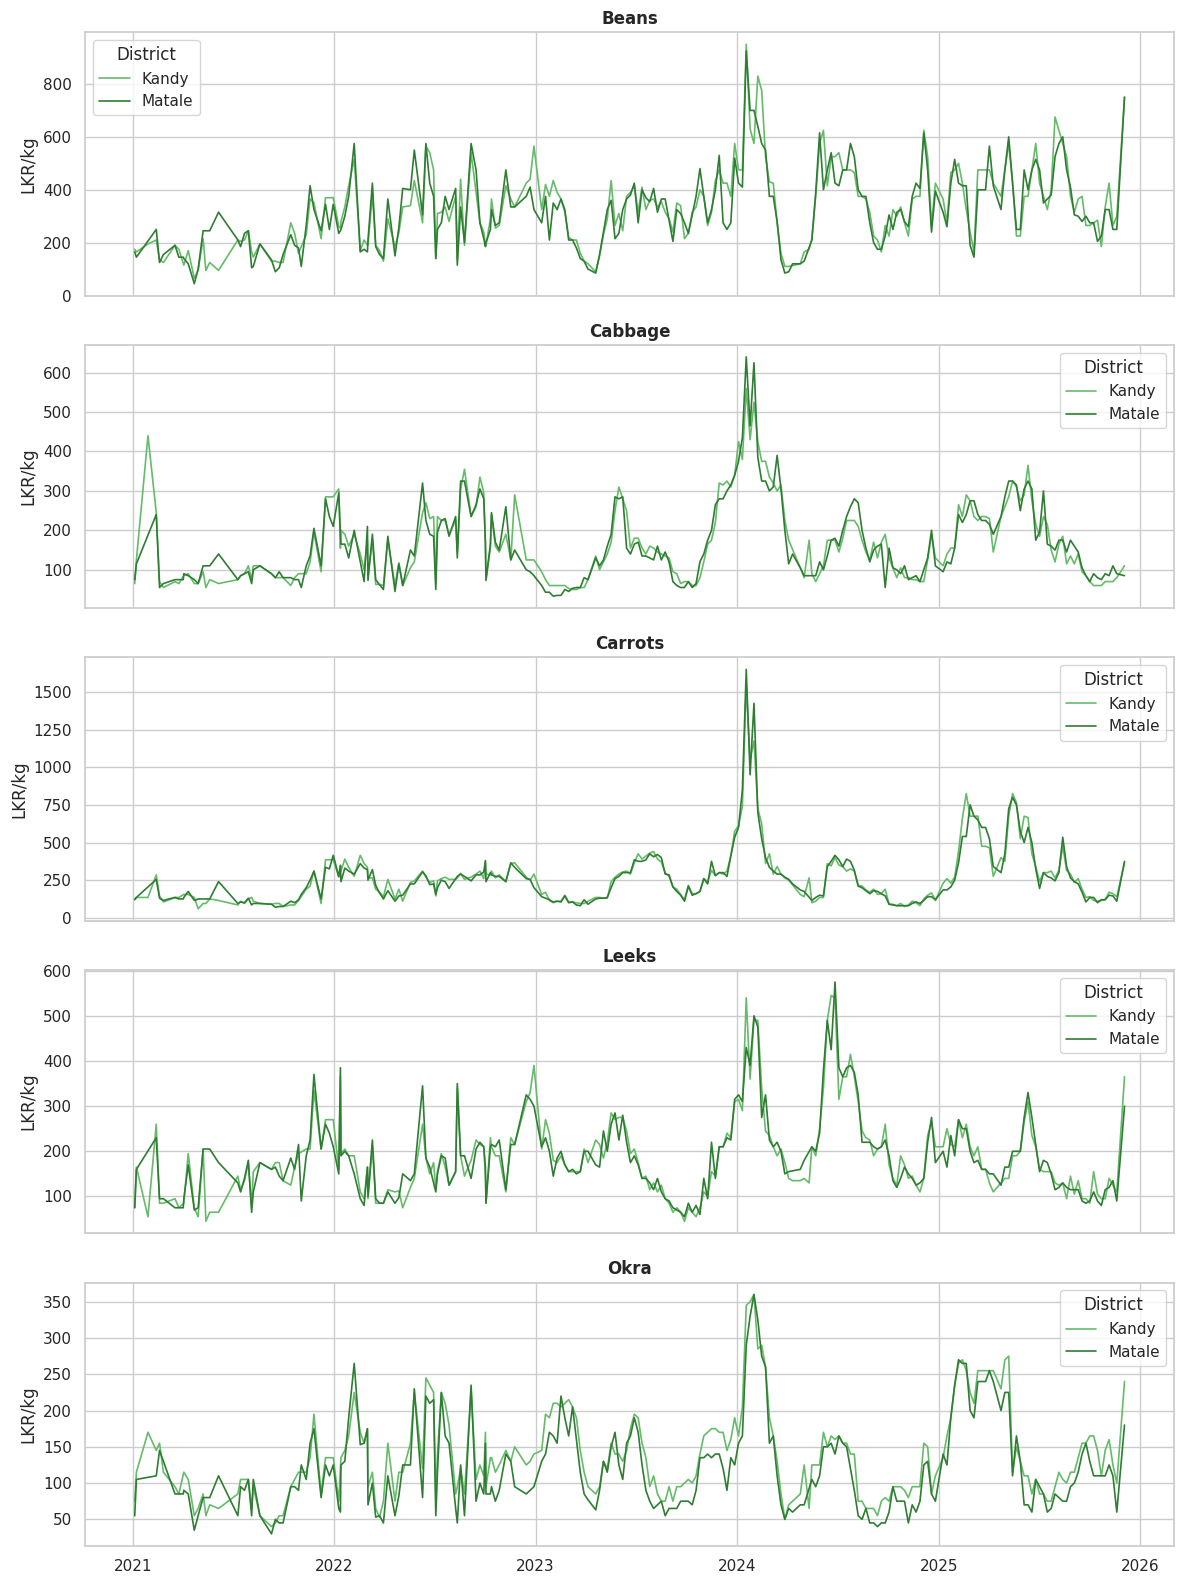

In [10]:
fig, axes = plt.subplots(len(df["Crop"].unique()), 1, figsize=(12, 16), sharex=True)
for ax, crop in zip(axes, sorted(df["Crop"].unique())):
    sub = df[df["Crop"] == crop]
    sns.lineplot(data=sub, x="Date", y="Price", hue="District", ax=ax,
                 palette=["#66BB6A", "#2E7D32"], linewidth=1.2)
    ax.set_title(crop)
    ax.set_ylabel("LKR/kg")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 8. Seasonality — average price by month

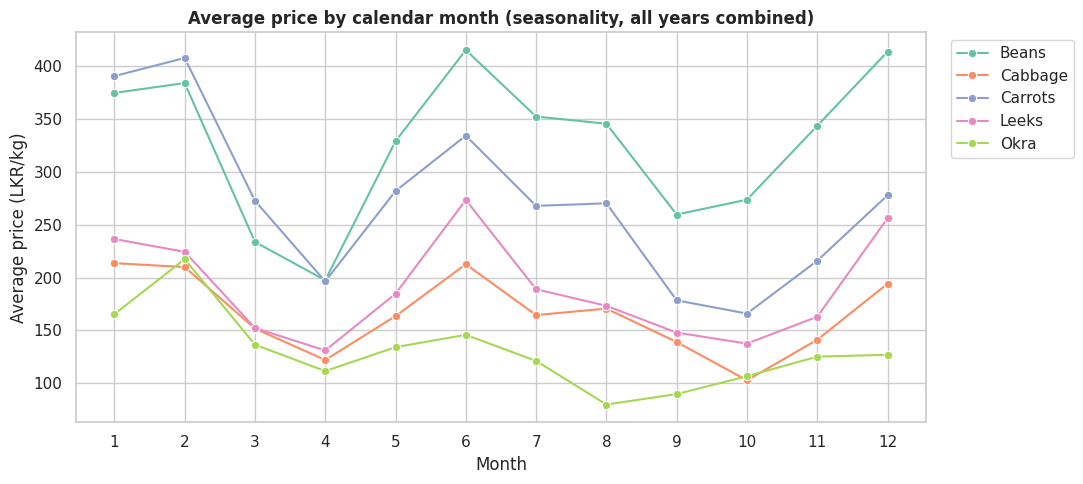

In [11]:
df["MonthNum"] = df["Date"].dt.month
monthly = df.groupby(["Crop", "MonthNum"])["Price"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly, x="MonthNum", y="Price", hue="Crop", marker="o", palette="Set2")
plt.xticks(range(1, 13))
plt.title("Average price by calendar month (seasonality, all years combined)")
plt.xlabel("Month")
plt.ylabel("Average price (LKR/kg)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [12]:
# Maha (Oct-Mar) vs Yala (Apr-Sep) season comparison, matching the AgriSense SDS seasons
def season(m):
    return "Maha" if m in (10, 11, 12, 1, 2, 3) else "Yala"

df["Season"] = df["MonthNum"].apply(season)
season_summary = df.groupby(["Crop", "Season"])["Price"].mean().unstack().round(1)
season_summary


Season,Maha,Yala
Crop,,
Beans,331.0,320.6
Cabbage,165.7,163.2
Carrots,284.1,256.5
Leeks,190.6,184.3
Okra,145.4,113.5


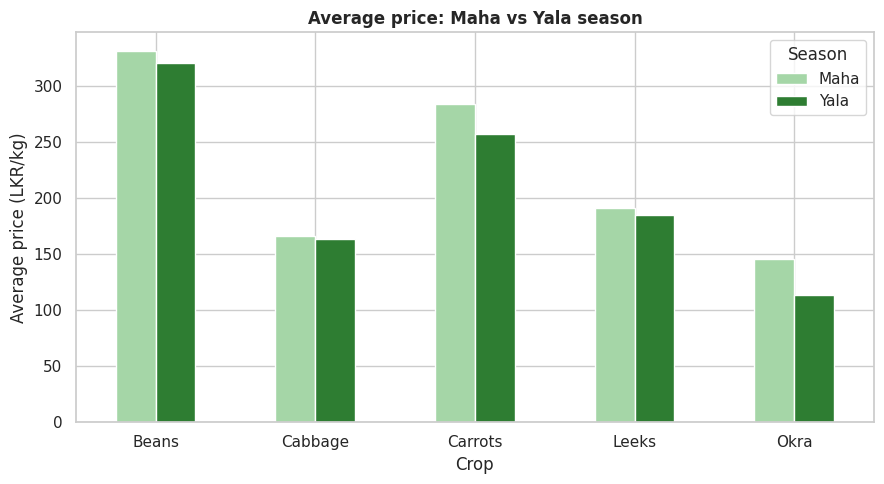

In [13]:
season_summary.plot(kind="bar", figsize=(9, 5), color=["#A5D6A7", "#2E7D32"])
plt.title("Average price: Maha vs Yala season")
plt.ylabel("Average price (LKR/kg)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Year-over-year trend

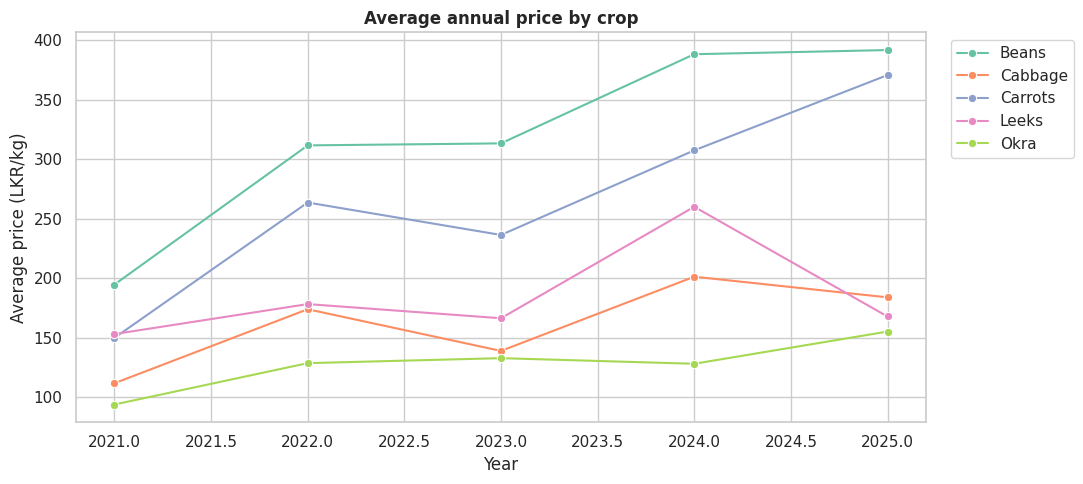

In [14]:
df["Year"] = df["Date"].dt.year
yearly = df.groupby(["Crop", "Year"])["Price"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=yearly, x="Year", y="Price", hue="Crop", marker="o", palette="Set2")
plt.title("Average annual price by crop")
plt.ylabel("Average price (LKR/kg)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 10. Volatility — which crops swing the most?

In [15]:
volatility = df.groupby("Crop")["Price"].agg(mean="mean", std="std")
volatility["coefficient_of_variation_%"] = (volatility["std"] / volatility["mean"] * 100).round(1)
volatility.sort_values("coefficient_of_variation_%", ascending=False)


,mean,std,coefficient_of_variation_%
Crop,,,
Carrots,270.170940,195.168550,72.2
Cabbage,164.405983,98.130156,59.7
Leeks,187.435897,89.972463,48.0
Okra,129.287393,61.442834,47.5
Beans,325.747863,144.239687,44.3


## 11. Outlier check (IQR method)

In [16]:
def iqr_outliers(group):
    q1, q3 = group["Price"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["Price"] < lower) | (group["Price"] > upper)]

outliers = df.groupby(["Crop", "District"], group_keys=False).apply(iqr_outliers)
print(f"{len(outliers)} potential outlier rows (outside 1.5x IQR per crop+district).")
outliers.sort_values("Price", ascending=False).head(20)


74 potential outlier rows (outside 1.5x IQR per crop+district).


,Date,Price,MonthNum,Season,Year
1402,2024-01-18,1650.0,1,Maha,2024
1397,2024-01-18,1550.0,1,Maha,2024
1422,2024-02-01,1425.0,2,Maha,2024
1417,2024-02-01,1175.0,2,Maha,2024
1407,2024-01-25,1050.0,1,Maha,2024
1412,2024-01-25,950.0,1,Maha,2024
1395,2024-01-18,950.0,1,Maha,2024
1400,2024-01-18,925.0,1,Maha,2024
1392,2024-01-11,850.0,1,Maha,2024
1425,2024-02-08,830.0,2,Maha,2024


## 12. Correlation between crop prices

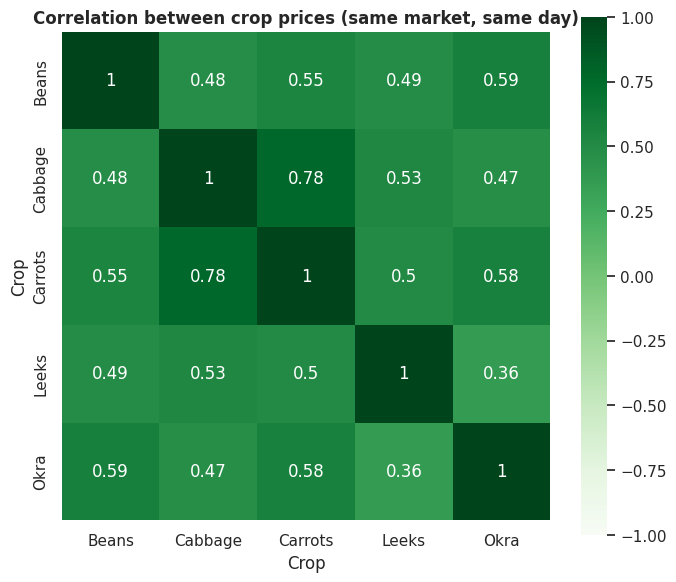

In [17]:
wide = df.pivot_table(index="Date", columns="Crop", values="Price", aggfunc="mean")
corr = wide.corr().round(2)

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="Greens", vmin=-1, vmax=1, square=True)
plt.title("Correlation between crop prices (same market, same day)")
plt.tight_layout()
plt.show()


## 13. Export model-ready datasets

- **Long format** (`agrisense_prices_clean.csv`) — tidy `Date, District, Crop, Price`, ready
  for the `price` table / general use.
- **Wide format** (`agrisense_prices_wide.csv`) — one column per crop, useful for correlation
  work or multi-output models.
- **Weekly-resampled per crop+district with lag features** — matches the 13-week lookback /
  4-week forecast setup used in the LSTM notebook.


In [18]:
df.to_csv("agrisense_prices_clean.csv", index=False)
wide.to_csv("agrisense_prices_wide.csv")
print("Saved agrisense_prices_clean.csv and agrisense_prices_wide.csv")


Saved agrisense_prices_clean.csv and agrisense_prices_wide.csv


In [19]:
# Weekly resample + lag/rolling features per (Crop, District) — feed straight into
# the LSTM notebook's windowing step.
feature_frames = []
for (crop, district), g in df.groupby(["Crop", "District"]):
    weekly = (
        g.set_index("Date")["Price"]
        .resample("W")
        .mean()
        .interpolate()
        .to_frame("price")
    )
    weekly["crop"] = crop
    weekly["district"] = district
    for lag in [1, 2, 3, 13]:
        weekly[f"lag_{lag}"] = weekly["price"].shift(lag)
    weekly["rolling_mean_4"] = weekly["price"].rolling(4).mean()
    weekly["rolling_std_4"] = weekly["price"].rolling(4).std()
    feature_frames.append(weekly.reset_index())

features = pd.concat(feature_frames, ignore_index=True)
features.to_csv("agrisense_prices_weekly_features.csv", index=False)
print("Saved agrisense_prices_weekly_features.csv —", features.shape)
features.dropna().head()


Saved agrisense_prices_weekly_features.csv — (2570, 10)


,Date,price,crop,district,lag_1,lag_2,lag_3,lag_13,rolling_mean_4,rolling_std_4
13,2021-04-11,170.0,Beans,Kandy,115.0,175.0,190.0,170.000000,162.500,32.787193
14,2021-04-18,117.5,Beans,Kandy,170.0,115.0,175.0,178.333333,144.375,32.556041
15,2021-04-25,65.0,Beans,Kandy,117.5,170.0,115.0,186.666667,116.875,42.884292
16,2021-05-02,95.0,Beans,Kandy,65.0,117.5,170.0,195.000000,111.875,44.317745
17,2021-05-09,215.0,Beans,Kandy,95.0,65.0,117.5,202.500000,123.125,64.915811
